# Podcast listening time - EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import KNNImputer

In [2]:
df = pd.read_csv('train.csv')

In [3]:
test = pd.read_csv('test.csv')

In [4]:
df

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,Learning Lab,Episode 25,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058
749996,749996,Business Briefs,Episode 21,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242
749997,749997,Lifestyle Lounge,Episode 51,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,749998,Style Guide,Episode 47,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           250000 non-null  int64  
 1   Podcast_Name                 250000 non-null  object 
 2   Episode_Title                250000 non-null  object 
 3   Episode_Length_minutes       221264 non-null  float64
 4   Genre                        250000 non-null  object 
 5   Host_Popularity_percentage   250000 non-null  float64
 6   Publication_Day              250000 non-null  object 
 7   Publication_Time             250000 non-null  object 
 8   Guest_Popularity_percentage  201168 non-null  float64
 9   Number_of_Ads                250000 non-null  float64
 10  Episode_Sentiment            250000 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 21.0+ MB


In [7]:
df.describe()

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,750000.000000,662907.000000,750000.000000,603970.000000,749999.000000,750000.000000
mean,374999.500000,64.504738,59.859901,52.236449,1.348855,45.437406
std,216506.495284,32.969603,22.873098,28.451241,1.151130,27.138306
min,0.000000,0.000000,1.300000,0.000000,0.000000,0.000000
25%,187499.750000,35.730000,39.410000,28.380000,0.000000,23.178350
50%,374999.500000,63.840000,60.050000,53.580000,1.000000,43.379460
75%,562499.250000,94.070000,79.530000,76.600000,2.000000,64.811580
max,749999.000000,325.240000,119.460000,119.910000,103.910000,119.970000


In [8]:
test.describe()

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads
count,250000.000000,2.212640e+05,250000.000000,201168.000000,250000.000000
mean,874999.500000,4.192987e+02,59.716491,52.192796,1.355852
std,72168.927986,1.668545e+05,22.880028,28.445034,4.274399
min,750000.000000,2.470000e+00,2.490000,0.000000,0.000000
25%,812499.750000,3.578000e+01,39.250000,28.320000,0.000000
50%,874999.500000,6.397000e+01,59.900000,53.360000,1.000000
75%,937499.250000,9.415000e+01,79.390000,76.560000,2.000000
max,999999.000000,7.848626e+07,117.760000,116.820000,2063.000000


Differences noted between training and test:
- episode length minutes: in test there's an even more extreme outlier to handle
- percentage (that should not surpass 100%...) of host popularity and guest popularity is in some cases > 100 in both training and test set
- number of ads must be cleaned in both training and test

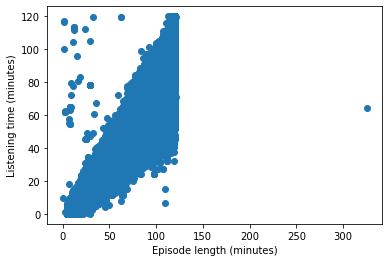

In [9]:
plt.figure()
plt.scatter(df['Episode_Length_minutes'], df['Listening_Time_minutes'])
plt.xlabel('Episode length (minutes)')
plt.ylabel('Listening time (minutes)')
plt.show()

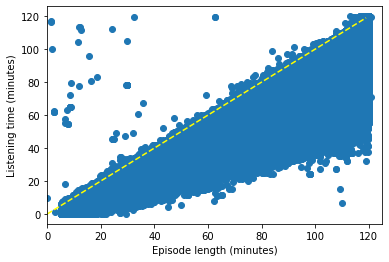

In [10]:
plt.figure()
plt.scatter(df['Episode_Length_minutes'], df['Listening_Time_minutes'])
plt.xlim([0,125])
plt.plot(np.arange(0,120), np.arange(0,120), '--', color='yellow')
plt.xlabel('Episode length (minutes)')
plt.ylabel('Listening time (minutes)')
plt.show()

In [11]:
import seaborn as sns

In [12]:
df['Number_of_Ads'].unique()

array([  0.  ,   2.  ,   3.  ,   1.  ,  53.37,    nan, 103.91, 103.  ,
        53.42, 103.75,  12.  , 103.25, 103.88])

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


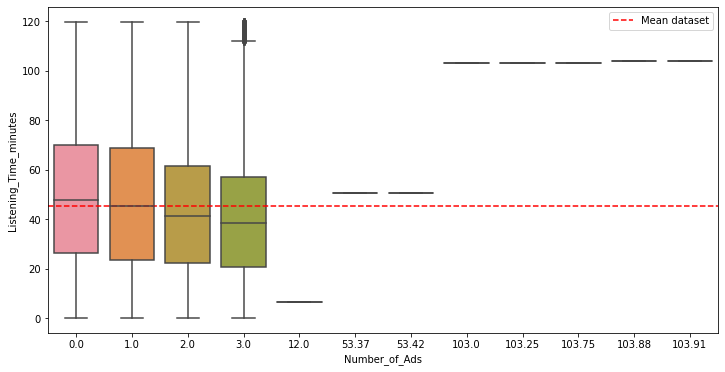

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(df['Number_of_Ads'], df['Listening_Time_minutes'])
plt.axhline(df['Listening_Time_minutes'].mean(), ls='--', c='r', label='Mean dataset')
plt.legend()

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


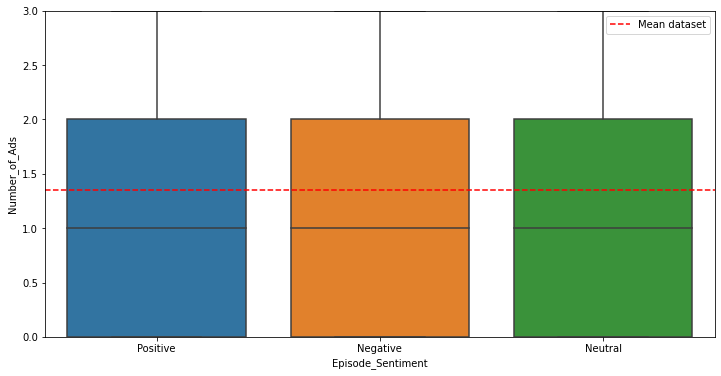

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(df['Episode_Sentiment'], df['Number_of_Ads'])
plt.axhline(df['Number_of_Ads'].mean(), ls='--', c='r', label='Mean dataset')
plt.ylim([0,3])
plt.legend()

In [15]:
df[df['Number_of_Ads']>3]

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
211159,211159,Wellness Wave,Episode 83,64.83,Health,48.46,Sunday,Evening,NaN,53.37,Positive,50.44892
283606,283606,Health Hour,Episode 15,109.93,Health,67.81,Sunday,Morning,77.90,103.91,Neutral,103.89696
436577,436577,Sports Central,Episode 64,115.25,Sports,28.58,Saturday,Afternoon,23.65,103.00,Neutral,103.12686
495919,495919,Comedy Corner,Episode 79,64.83,Comedy,48.37,Saturday,Evening,NaN,53.42,Neutral,50.44892
537705,537705,Sound Waves,Episode 64,112.27,Music,28.95,Saturday,Morning,10.15,103.75,Neutral,103.12686
567235,567235,Detective Diaries,Episode 21,16.13,True Crime,49.11,Tuesday,Evening,43.17,12.00,Positive,6.49000
602553,602553,Sound Waves,Episode 53,112.27,Music,28.19,Tuesday,Morning,23.15,103.25,Neutral,103.12686
672139,672139,Sound Waves,Episode 35,115.74,Music,28.95,Tuesday,Afternoon,23.50,103.25,Neutral,103.12686
683147,683147,Crime Chronicles,Episode 15,109.93,True Crime,59.66,Tuesday,Evening,77.91,103.88,Neutral,103.89696


In [16]:
test[test['Number_of_Ads']>3]

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
37939,787939,Life Lessons,Episode 94,89.84,Lifestyle,60.79,Sunday,Afternoon,62.13,89.12,Neutral
178393,928393,Tech Trends,Episode 59,7.15,Technology,71.90,Sunday,Morning,17.39,2063.00,Positive


C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


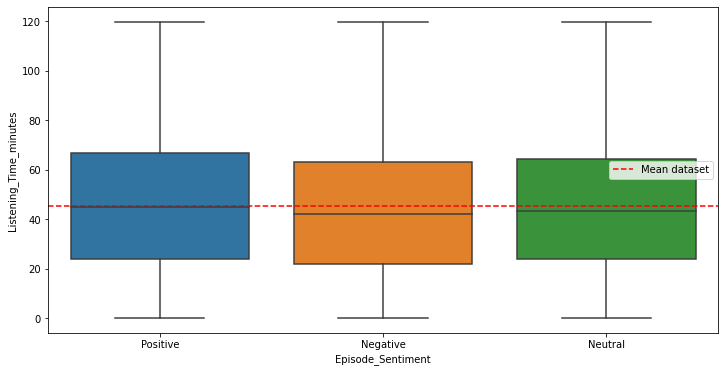

In [17]:
plt.figure(figsize=(12,6))
sns.boxplot(df['Episode_Sentiment'], df['Listening_Time_minutes'])
plt.axhline(df['Listening_Time_minutes'].mean(), ls='--', c='r', label='Mean dataset')
plt.legend()

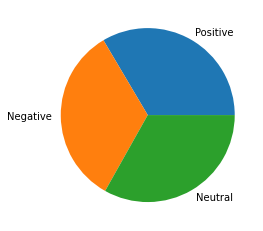

In [18]:
plt.pie(df['Episode_Sentiment'].value_counts(), labels=df['Episode_Sentiment'].unique())
plt.show()

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


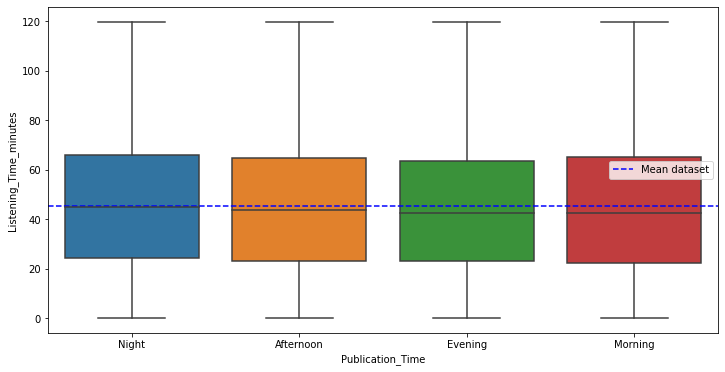

In [19]:
plt.figure(figsize=(12,6))
sns.boxplot(df['Publication_Time'], df['Listening_Time_minutes'])
plt.axhline(df['Listening_Time_minutes'].mean(), ls='--', c='b', label='Mean dataset')
plt.legend()

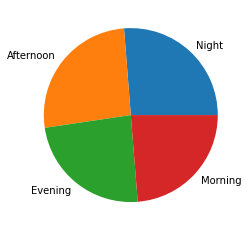

In [20]:
plt.pie(df['Publication_Time'].value_counts(), labels=df['Publication_Time'].unique())
plt.show()

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


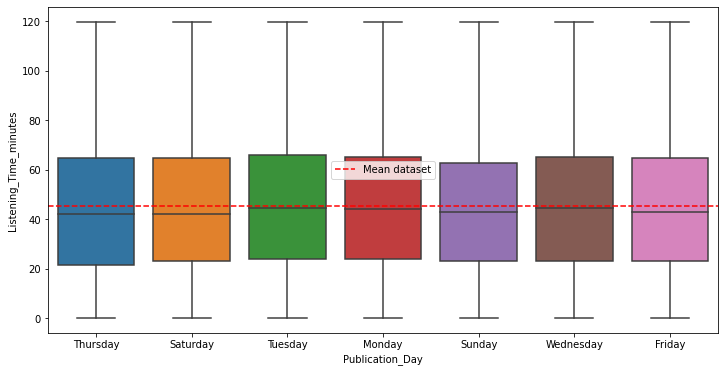

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(df['Publication_Day'], df['Listening_Time_minutes'])
plt.axhline(df['Listening_Time_minutes'].mean(), ls='--', c='r', label='Mean dataset')
plt.legend()

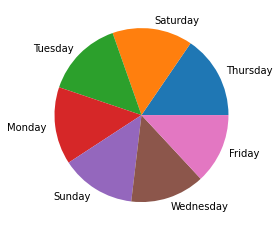

In [22]:
plt.pie(df['Publication_Day'].value_counts(), labels=df['Publication_Day'].unique())
plt.show()

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


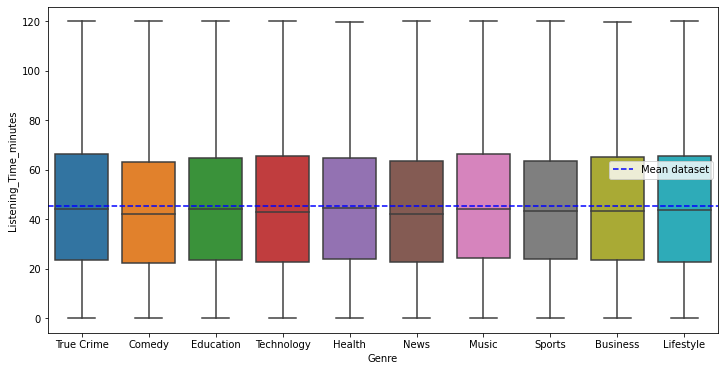

In [23]:
plt.figure(figsize=(12,6))
sns.boxplot(df['Genre'], df['Listening_Time_minutes'])
plt.axhline(df['Listening_Time_minutes'].mean(), ls='--', c='b', label='Mean dataset')
plt.legend()

In [24]:
df['episode number'] = df.apply(lambda x: float(x['Episode_Title'].split(" ")[1]), axis=1)

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


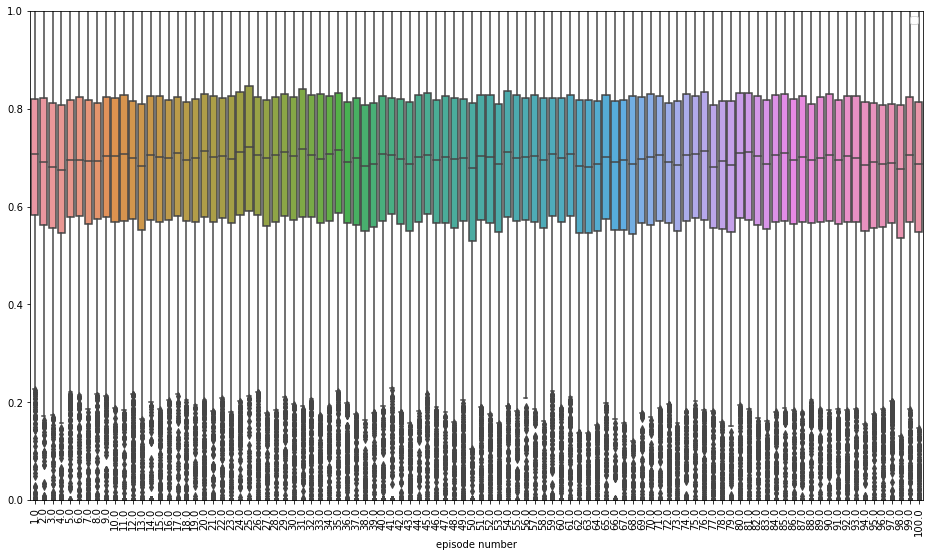

In [30]:
plt.figure(figsize=(16,9))
sns.boxplot(df[df['Episode_Length_minutes']!=0]['episode number'], (df[df['Episode_Length_minutes']!=0]['Listening_Time_minutes'])/df[df['Episode_Length_minutes']!=0]['Episode_Length_minutes'])
plt.legend()
plt.xticks(rotation=90)
plt.ylim([0,1])
plt.show()

In [ ]:
plt.figure(figsize=(16,9))
sns.boxplot(df['Podcast_Name'], df['Episode_Length_minutes'])
plt.axhline(df['Episode_Length_minutes'].mean(), ls='--', c='b', label='Mean dataset')
plt.legend()
plt.xticks(rotation=90)
plt.ylim([0,120])
plt.show()

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


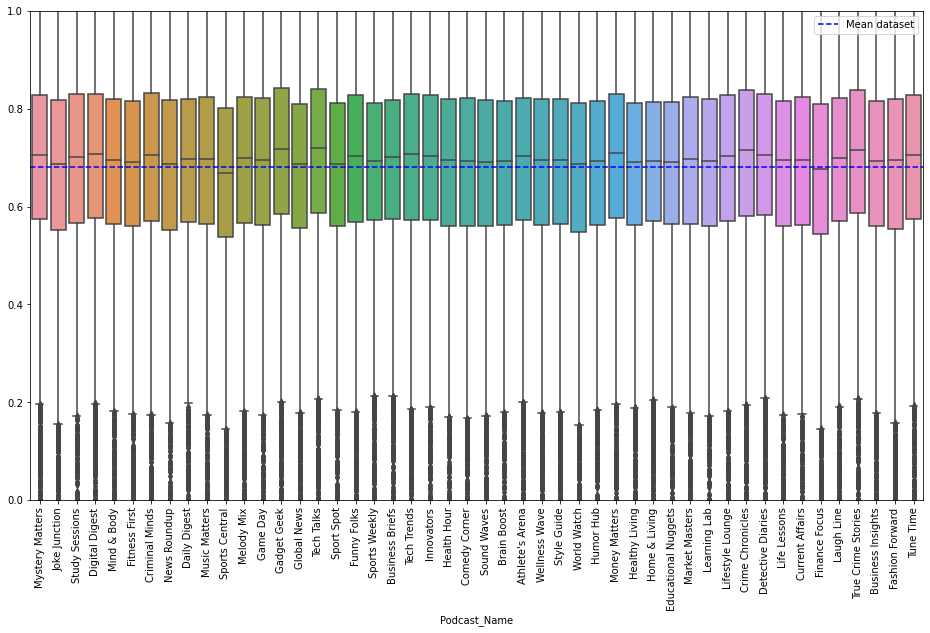

In [35]:
plt.figure(figsize=(16,9))
sns.boxplot(df['Podcast_Name'], (df[df['Episode_Length_minutes']!=0]['Listening_Time_minutes'])/df[df['Episode_Length_minutes']!=0]['Episode_Length_minutes'])
plt.axhline(((df[df['Episode_Length_minutes']!=0]['Listening_Time_minutes'])/df[df['Episode_Length_minutes']!=0]['Episode_Length_minutes']).mean(), ls='--', c='b', label='Mean dataset')
plt.legend()
plt.xticks(rotation=90)
plt.ylim([0,1])
plt.show()

In [ ]:
plt.figure(figsize=(16,9))
sns.boxplot(df['Podcast_Name'], df['Listening_Time_minutes'])
plt.axhline(df['Listening_Time_minutes'].mean(), ls='--', c='r', label='Mean dataset')
plt.legend()
plt.xticks(rotation=90)
plt.show()

In [ ]:
count = 0
for episode in df['Podcast_Name'].unique():
    if episode not in test['Podcast_Name'].unique():
        print("Episode " + episode + " is not in test")
        count +=1
        
for episode in test['Podcast_Name'].unique():
    if episode not in df['Podcast_Name'].unique():
        print("Episode " + episode + " is not in training")
        count +=1
if count == 0:
    print("Training and test have the same podcasts")

In [ ]:
plt.pie(df[df['Listening_Time_minutes']<1]['Publication_Day'].value_counts(), labels=df[df['Listening_Time_minutes']<1]['Publication_Day'].unique())
plt.show()

In [ ]:
plt.pie(df[df['Listening_Time_minutes']<1]['Genre'].value_counts(), labels=df[df['Listening_Time_minutes']<1]['Genre'].unique())
plt.show()

In [ ]:
plt.pie(df[df['Listening_Time_minutes']<1]['Publication_Time'].value_counts(), labels=df[df['Listening_Time_minutes']<1]['Publication_Time'].unique())
plt.show()

In [37]:
from sklearn import tree
from sklearn.impute import KNNImputer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics import explained_variance_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder  

In [38]:
df.loc[df['Episode_Sentiment']=='Negative','Episode_Sentiment']=0
df.loc[df['Episode_Sentiment']=='Neutral','Episode_Sentiment']=1
df.loc[df['Episode_Sentiment']=='Positive','Episode_Sentiment']=2
df['Episode_Sentiment'] = pd.to_numeric(df['Episode_Sentiment'].values)

In [39]:
df.loc[df['Publication_Day']=='Monday','Publication_Day']=0
df.loc[df['Publication_Day']=='Tuesday','Publication_Day']=1
df.loc[df['Publication_Day']=='Wednesday','Publication_Day']=2
df.loc[df['Publication_Day']=='Thursday','Publication_Day']=3
df.loc[df['Publication_Day']=='Friday','Publication_Day']=4
df.loc[df['Publication_Day']=='Saturday','Publication_Day']=5
df.loc[df['Publication_Day']=='Sunday','Publication_Day']=6
df['Publication_Day'] = pd.to_numeric(df['Publication_Day'].values)

In [40]:
df.loc[df['Publication_Time']=='Morning','Publication_Time']=0
df.loc[df['Publication_Time']=='Afternoon','Publication_Time']=1
df.loc[df['Publication_Time']=='Evening','Publication_Time']=2
df.loc[df['Publication_Time']=='Night','Publication_Time']=2
df['Publication_Time'] = pd.to_numeric(df['Publication_Time'].values)

In [41]:
df1 = df.loc[df['Episode_Length_minutes'].notnull() & (df['Number_of_Ads']).notnull() & (df['Guest_Popularity_percentage'].notnull())]

one_hot_data = pd.get_dummies(df1[['Podcast_Name', 'Genre']],drop_first=True, dtype=float)
one_hot_data['Episode_Sentiment'] = df1['Episode_Sentiment']
one_hot_data['Publication_Time'] = df1['Publication_Time']
one_hot_data['Publication_Day'] = df1['Publication_Day']
one_hot_data['Episode_Length_minutes'] = df1['Episode_Length_minutes']
one_hot_data['Host_Popularity_percentage'] = df1['Host_Popularity_percentage']
one_hot_data['Guest_Popularity_percentage'] = df1['Guest_Popularity_percentage']
one_hot_data['Number_of_Ads'] = df1['Number_of_Ads']
one_hot_data['episode number'] = df1['episode number']

In [55]:
one_hot_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 539048 entries, 1 to 749999
Data columns (total 64 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Podcast_Name_Brain Boost          539048 non-null  float64
 1   Podcast_Name_Business Briefs      539048 non-null  float64
 2   Podcast_Name_Business Insights    539048 non-null  float64
 3   Podcast_Name_Comedy Corner        539048 non-null  float64
 4   Podcast_Name_Crime Chronicles     539048 non-null  float64
 5   Podcast_Name_Criminal Minds       539048 non-null  float64
 6   Podcast_Name_Current Affairs      539048 non-null  float64
 7   Podcast_Name_Daily Digest         539048 non-null  float64
 8   Podcast_Name_Detective Diaries    539048 non-null  float64
 9   Podcast_Name_Digital Digest       539048 non-null  float64
 10  Podcast_Name_Educational Nuggets  539048 non-null  float64
 11  Podcast_Name_Fashion Forward      539048 non-null  f

In [ ]:
one_hot_data.iloc[:,[idx for idx in range(len(one_hot_data.columns)) if idx!=59]]

In [42]:
model1 = DecisionTreeRegressor(max_depth =8)
X = one_hot_data.iloc[:,[idx for idx in range(len(one_hot_data.columns)) if idx!=59]]
y = one_hot_data.iloc[:,59]
model1.fit(X, y)

model2 = DecisionTreeRegressor(max_depth =8)
X = one_hot_data.iloc[:,[idx for idx in range(len(one_hot_data.columns)) if idx!=62]]
y = one_hot_data.iloc[:,62]
model2.fit(X, y)

model3 = DecisionTreeRegressor(max_depth =8)
X = one_hot_data.iloc[:,[idx for idx in range(len(one_hot_data.columns)) if idx!=61]]
y = one_hot_data.iloc[:,61]
model3.fit(X, y)

DecisionTreeRegressor(max_depth=8)

In [43]:
df2 = df.loc[df['Episode_Length_minutes'].isnull()]
one_hot_data = pd.get_dummies(df2[['Podcast_Name', 'Genre']],drop_first=True, dtype=float)
one_hot_data['Episode_Sentiment'] = df2['Episode_Sentiment']
one_hot_data['Publication_Time'] = df2['Publication_Time']
one_hot_data['Publication_Day'] = df2['Publication_Day']
one_hot_data['Episode_Length_minutes'] = df2['Episode_Length_minutes']
one_hot_data['Host_Popularity_percentage'] = df2['Host_Popularity_percentage']
one_hot_data['Guest_Popularity_percentage'] = df2['Guest_Popularity_percentage']
one_hot_data['Number_of_Ads'] = df2['Number_of_Ads']
one_hot_data['episode number'] = df2['episode number']
X = one_hot_data.iloc[:,[idx for idx in range(len(one_hot_data.columns)) if idx!=59]]

correct1 = model1.predict(X)

In [44]:
df2 = df.loc[df['Guest_Popularity_percentage'].isnull()]
one_hot_data = pd.get_dummies(df2[['Podcast_Name', 'Genre']],drop_first=True, dtype=float)
one_hot_data['Episode_Sentiment'] = df2['Episode_Sentiment']
one_hot_data['Publication_Time'] = df2['Publication_Time']
one_hot_data['Publication_Day'] = df2['Publication_Day']
one_hot_data['Episode_Length_minutes'] = df2['Episode_Length_minutes']
one_hot_data['Host_Popularity_percentage'] = df2['Host_Popularity_percentage']
one_hot_data['Guest_Popularity_percentage'] = df2['Guest_Popularity_percentage']
one_hot_data['Number_of_Ads'] = df2['Number_of_Ads']
one_hot_data['episode number'] = df2['episode number']
X = one_hot_data.iloc[:,[idx for idx in range(len(one_hot_data.columns)) if idx!=61]]

correct3 = model3.predict(X)

In [ ]:
len(correct3)

In [ ]:
df.info()

In [ ]:
df.loc[(df['Guest_Popularity_percentage'].isnull()),'Guest_Popularity_percentage'] = correct3
df.loc[df['Episode_Length_minutes'].isnull(),'Episode_Length_minutes'] = correct1
df.info()

imputer = KNNImputer(n_neighbors=1)
df_imputed = imputer.fit_transform(df[['Episode_Length_minutes',
                                       'Host_Popularity_percentage', 'Publication_Day',
                                       'Publication_Time', 'Guest_Popularity_percentage', 'Number_of_Ads',
                                       'Episode_Sentiment', 'Listening_Time_minutes', 'episode number']])

df['Episode_Length_minutes'] = df_imputed[0]
df['Number_of_Ads'] = df_imputed[5]
df['Guest_Popularity_percentage'] = df_imputed[4]

In [ ]:
df.loc[df['Episode_Length_minutes'].isnull(),'Episode_Length_minutes'] = df['Episode_Length_minutes'].mean()
df.loc[df['Number_of_Ads'].isnull(),'Number_of_Ads'] = df['Number_of_Ads'].mean()
df.loc[df['Guest_Popularity_percentage'].isnull(),'Guest_Popularity_percentage'] = df['Guest_Popularity_percentage'].mean()

In [45]:
df = df.loc[df['Episode_Length_minutes'].notnull() & (df['Number_of_Ads']).notnull() & (df['Guest_Popularity_percentage'].notnull())]

In [ ]:
df.info()

In [46]:
one_hot_data = pd.get_dummies(df[['Podcast_Name', 'Genre']],drop_first=True, dtype=float)
one_hot_data['Episode_Sentiment'] = df['Episode_Sentiment']
one_hot_data['Publication_Time'] = df['Publication_Time']
one_hot_data['Publication_Day'] = df['Publication_Day']
one_hot_data['Episode_Length_minutes'] = df['Episode_Length_minutes']
one_hot_data['Host_Popularity_percentage'] = df['Host_Popularity_percentage']
one_hot_data['Guest_Popularity_percentage'] = df['Guest_Popularity_percentage']
one_hot_data['Number_of_Ads'] = df['Number_of_Ads']
one_hot_data['episode number'] = df['episode number']

In [47]:
X = one_hot_data
#X = df.iloc[:,:11]
y = df.iloc[:,11]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [ ]:
models_and_hyperparams = {'RandomForestRegressor': (RandomForestRegressor(),
                                                     {'criterion': ['squared_error'],
                                                      'n_estimators': [4], 
                                                      'max_depth': [i for i in range(1, X.shape[1]+1)],
                                                     'min_samples_leaf':[2,4,8]}
                                                    )
                         }

In [ ]:
# when we train on a certain fold, we use a second cross-validation
# split in order to choose hyperparameters
inner_cv = KFold(n_splits=2, shuffle=True, random_state=10)

chosen_metric = 'neg_root_mean_squared_error'
# we will collect the average of the scores on the 10 outer folds in this dictionary
# with keys given by the names of the models in `models_and_hyperparams`
average_scores_across_outer_folds_for_each_model = dict()

for name, (model, params) in models_and_hyperparams.items():
    print(name + " model")
    # this object is a classifier that also happens to choose
    # its hyperparameters automatically using `inner_cv`
    model_optimizing_hyperparams = GridSearchCV(estimator=model,param_grid=params,cv=inner_cv, 
                                                scoring=chosen_metric,verbose=True,n_jobs=-1)

    # estimate generalization error on the 10-fold splits of the data
    model_optimizing_hyperparams.fit(X_train, y_train)
    
    print('Best parameter choice for this model: \n\t{params}'
          '\n(according to cross-validation `{cv}` on the whole dataset).'.format(
          params=model_optimizing_hyperparams.best_params_, cv=inner_cv))

In [ ]:
perf_rf = {}

In [48]:
n_estimators = 32

In [51]:
model = RandomForestRegressor(n_estimators = n_estimators
                              )
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=32)

In [52]:
print("MAPE on train: ", root_mean_squared_error(y_train.values, model.predict(X_train)))
print("MAPE on test: ", root_mean_squared_error(y_test.values, model.predict(X_test)))

MAPE on train:  3.908663304558363
MAPE on test:  10.106593093910192


In [53]:
model.fit(X, y)

RandomForestRegressor(n_estimators=32)

In [ ]:
perf_rf[n_estimators] = {"MAPE on train" :root_mean_squared_error(y_train.values, model.predict(X_train)),
                      "MAPE on test": root_mean_squared_error(y_test.values, model.predict(X_test))}

In [ ]:
perf_rf

In [ ]:
plt.figure()
plt.bar(['Train', 'Test'], [root_mean_squared_error(y_train, model.predict(X_train)),
                            root_mean_squared_error(y_test, model.predict(X_test))])
plt.show()

In [36]:
import shap

In [ ]:
shap.summary_plot(shap_values)

In [ ]:
#from sklearn.tree import plot_tree
#plt.figure(figsize=(14,7))
#plot_tree(model, feature_names = one_hot_data.columns, label = 'none', filled=True, proportion=True)
#plt.savefig('Tree.pdf')
#plt.show()

In [54]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           250000 non-null  int64  
 1   Podcast_Name                 250000 non-null  object 
 2   Episode_Title                250000 non-null  object 
 3   Episode_Length_minutes       221264 non-null  float64
 4   Genre                        250000 non-null  object 
 5   Host_Popularity_percentage   250000 non-null  float64
 6   Publication_Day              250000 non-null  object 
 7   Publication_Time             250000 non-null  object 
 8   Guest_Popularity_percentage  201168 non-null  float64
 9   Number_of_Ads                250000 non-null  float64
 10  Episode_Sentiment            250000 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 21.0+ MB


In [56]:
test['episode number'] = test.apply(lambda x: float(x['Episode_Title'].split(" ")[1]), axis=1)

test.loc[test['Episode_Sentiment']=='Negative','Episode_Sentiment']=0
test.loc[test['Episode_Sentiment']=='Neutral','Episode_Sentiment']=1
test.loc[test['Episode_Sentiment']=='Positive','Episode_Sentiment']=2
test['Episode_Sentiment'] = pd.to_numeric(test['Episode_Sentiment'].values)

test.loc[test['Publication_Day']=='Monday','Publication_Day']=0
test.loc[test['Publication_Day']=='Tuesday','Publication_Day']=1
test.loc[test['Publication_Day']=='Wednesday','Publication_Day']=2
test.loc[test['Publication_Day']=='Thursday','Publication_Day']=3
test.loc[test['Publication_Day']=='Friday','Publication_Day']=4
test.loc[test['Publication_Day']=='Saturday','Publication_Day']=5
test.loc[test['Publication_Day']=='Sunday','Publication_Day']=6
test['Publication_Day'] = pd.to_numeric(test['Publication_Day'].values)

test.loc[test['Publication_Time']=='Morning','Publication_Time']=0
test.loc[test['Publication_Time']=='Afternoon','Publication_Time']=1
test.loc[test['Publication_Time']=='Evening','Publication_Time']=2
test.loc[test['Publication_Time']=='Night','Publication_Time']=2
test['Publication_Time'] = pd.to_numeric(test['Publication_Time'].values)

In [58]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           250000 non-null  int64  
 1   Podcast_Name                 250000 non-null  object 
 2   Episode_Title                250000 non-null  object 
 3   Episode_Length_minutes       221264 non-null  float64
 4   Genre                        250000 non-null  object 
 5   Host_Popularity_percentage   250000 non-null  float64
 6   Publication_Day              250000 non-null  int64  
 7   Publication_Time             250000 non-null  int64  
 8   Guest_Popularity_percentage  201168 non-null  float64
 9   Number_of_Ads                250000 non-null  float64
 10  Episode_Sentiment            250000 non-null  int64  
 11  episode number               250000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 22.9+ MB


In [68]:
df2 = test.loc[test['Episode_Length_minutes'].isnull()]
one_hot_data = pd.get_dummies(df2[['Podcast_Name', 'Genre']],drop_first=True, dtype=float)
one_hot_data['Episode_Sentiment'] = df2['Episode_Sentiment']
one_hot_data['Publication_Time'] = df2['Publication_Time']
one_hot_data['Publication_Day'] = df2['Publication_Day']
one_hot_data['Episode_Length_minutes'] = df2['Episode_Length_minutes']
one_hot_data['Host_Popularity_percentage'] = df2['Host_Popularity_percentage']
one_hot_data['Guest_Popularity_percentage'] = df2['Guest_Popularity_percentage']
one_hot_data['Number_of_Ads'] = df2['Number_of_Ads']
one_hot_data['episode number'] = df2['episode number']
X = one_hot_data.iloc[:,[idx for idx in range(len(one_hot_data.columns)) if idx!=59]]

correct1 = model1.predict(X)

In [69]:
df2 = test.loc[test['Guest_Popularity_percentage'].isnull()]
one_hot_data = pd.get_dummies(df2[['Podcast_Name', 'Genre']],drop_first=True, dtype=float)
one_hot_data['Episode_Sentiment'] = df2['Episode_Sentiment']
one_hot_data['Publication_Time'] = df2['Publication_Time']
one_hot_data['Publication_Day'] = df2['Publication_Day']
one_hot_data['Episode_Length_minutes'] = df2['Episode_Length_minutes']
one_hot_data['Host_Popularity_percentage'] = df2['Host_Popularity_percentage']
one_hot_data['Guest_Popularity_percentage'] = df2['Guest_Popularity_percentage']
one_hot_data['Number_of_Ads'] = df2['Number_of_Ads']
one_hot_data['episode number'] = df2['episode number']
X = one_hot_data.iloc[:,[idx for idx in range(len(one_hot_data.columns)) if idx!=61]]

correct3 = model3.predict(X)

In [70]:
len(correct1)

28736

In [71]:
test.loc[(test['Guest_Popularity_percentage'].isnull()),'Guest_Popularity_percentage'] = correct3
test.loc[test['Episode_Length_minutes'].isnull(),'Episode_Length_minutes'] = correct1

In [72]:
one_hot_data = pd.get_dummies(test[['Podcast_Name', 'Genre']],drop_first=True, dtype=float)
one_hot_data['Episode_Sentiment'] = test['Episode_Sentiment']
one_hot_data['Publication_Time'] = test['Publication_Time']
one_hot_data['Publication_Day'] = test['Publication_Day']
one_hot_data['Episode_Length_minutes'] = test['Episode_Length_minutes']
one_hot_data['Host_Popularity_percentage'] = test['Host_Popularity_percentage']
one_hot_data['Guest_Popularity_percentage'] = test['Guest_Popularity_percentage']
one_hot_data['Number_of_Ads'] = test['Number_of_Ads']
one_hot_data['episode number'] = test['episode number']

In [73]:
model.predict(one_hot_data)

array([61.79913   , 18.09800281, 49.87292844, ...,  7.25415219,
       70.75219344, 60.0992075 ])

In [74]:
d = {'id': test['id'], 'Listening_Time_minutes': model.predict(one_hot_data)}
df = pd.DataFrame(data=d)
df = df.round(decimals = 3)
df

,id,Listening_Time_minutes
0,750000,61.799
1,750001,18.098
2,750002,49.873
3,750003,76.454
4,750004,46.128
...,...,...
249995,999995,11.018
249996,999996,55.264
249997,999997,7.254
249998,999998,70.752


In [75]:
df.to_csv('results.csv', sep=',', index=False)

In [ ]:
df['Listening_Time_minutes']